In [2]:
# Import Required Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Display plots inside notebook
%matplotlib inline

print("Libraries imported successfully.")

Libraries imported successfully.


In [3]:
# Load the dataset

df = pd.read_csv("../data/datafile (1).csv")

In [4]:
# Display first 5 rows

df.head()

,Crop,State,Cost of Cultivation (`/Hectare) A2+FL,Cost of Cultivation (`/Hectare) C2,Cost of Production (`/Quintal) C2,Yield (Quintal/ Hectare)
0,ARHAR,Uttar Pradesh,9794.05,23076.74,1941.55,9.83
1,ARHAR,Karnataka,10593.15,16528.68,2172.46,7.47
2,ARHAR,Gujarat,13468.82,19551.90,1898.30,9.59
3,ARHAR,Andhra Pradesh,17051.66,24171.65,3670.54,6.42
4,ARHAR,Maharashtra,17130.55,25270.26,2775.80,8.72


In [5]:
# Number of rows and columns

print("Shape of Dataset:", df.shape)

Shape of Dataset: (49, 6)


In [7]:
# Display dataset information

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 49 entries, 0 to 48
Data columns (total 6 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   Crop                                   49 non-null     str    
 1   State                                  49 non-null     str    
 2   Cost of Cultivation (`/Hectare) A2+FL  49 non-null     float64
 3   Cost of Cultivation (`/Hectare) C2     49 non-null     float64
 4   Cost of Production (`/Quintal) C2      49 non-null     float64
 5   Yield (Quintal/ Hectare)               49 non-null     float64
dtypes: float64(4), str(2)
memory usage: 3.3 KB


In [8]:
# Summary statistics

df.describe()

,Cost of Cultivation (`/Hectare) A2+FL,Cost of Cultivation (`/Hectare) C2,Cost of Production (`/Quintal) C2,Yield (Quintal/ Hectare)
count,49.000000,49.000000,49.000000,49.000000
mean,20363.537347,31364.666735,1620.537755,98.086735
std,13561.435306,20095.783569,1104.990472,245.293123
min,5483.540000,7868.640000,85.790000,1.320000
25%,12774.410000,19259.840000,732.620000,9.590000
50%,17022.000000,25909.050000,1595.560000,13.700000
75%,24731.060000,35423.480000,2228.970000,36.610000
max,66335.060000,91442.630000,5777.480000,1015.450000


In [9]:
# Check for missing values

df.isnull().sum()

Crop                                     0
State                                    0
Cost of Cultivation (`/Hectare) A2+FL    0
Cost of Cultivation (`/Hectare) C2       0
Cost of Production (`/Quintal) C2        0
Yield (Quintal/ Hectare)                 0
dtype: int64

In [10]:
# Check duplicate records

df.duplicated().sum()

np.int64(0)

In [11]:
# Rename columns

df.columns = [
    "Crop",
    "State",
    "Cultivation_Cost_A2FL",
    "Cultivation_Cost_C2",
    "Production_Cost_C2",
    "Yield"
]

df.head()

,Crop,State,Cultivation_Cost_A2FL,Cultivation_Cost_C2,Production_Cost_C2,Yield
0,ARHAR,Uttar Pradesh,9794.05,23076.74,1941.55,9.83
1,ARHAR,Karnataka,10593.15,16528.68,2172.46,7.47
2,ARHAR,Gujarat,13468.82,19551.90,1898.30,9.59
3,ARHAR,Andhra Pradesh,17051.66,24171.65,3670.54,6.42
4,ARHAR,Maharashtra,17130.55,25270.26,2775.80,8.72


In [12]:
# Verify renamed columns

df.columns

Index(['Crop', 'State', 'Cultivation_Cost_A2FL', 'Cultivation_Cost_C2',
       'Production_Cost_C2', 'Yield'],
      dtype='str')

In [13]:
# Display unique crops

print("Number of Crops:", df["Crop"].nunique())
print("\nCrop Names:\n")
print(df["Crop"].unique())

Number of Crops: 10

Crop Names:

<ArrowStringArray>
[               'ARHAR',               'COTTON',                 'GRAM',
            'GROUNDNUT',                'MAIZE',                'MOONG',
                'PADDY', 'RAPESEED AND MUSTARD',            'SUGARCANE',
                'WHEAT']
Length: 10, dtype: str


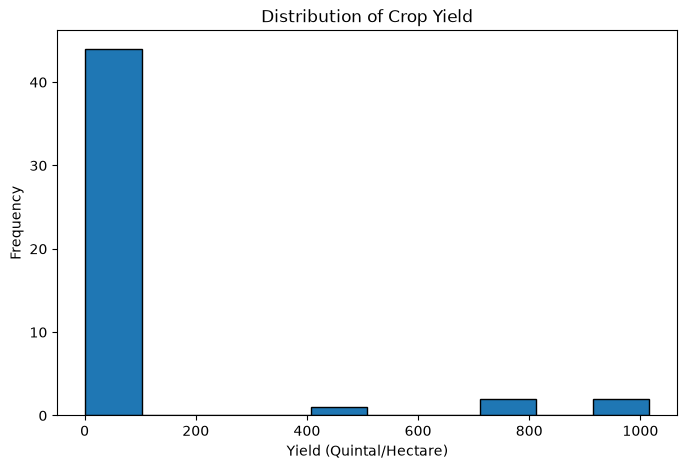

In [14]:
plt.figure(figsize=(8,5))

plt.hist(df["Yield"], bins=10, edgecolor="black")

plt.title("Distribution of Crop Yield")
plt.xlabel("Yield (Quintal/Hectare)")
plt.ylabel("Frequency")

plt.show()

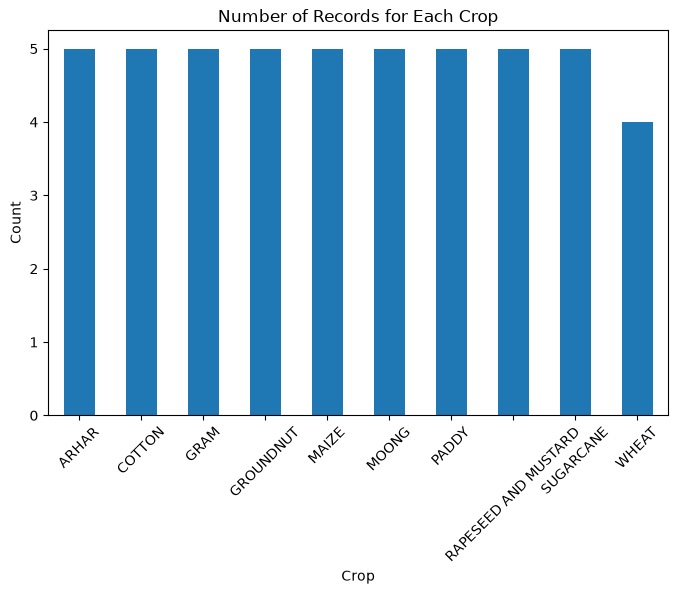

In [15]:
plt.figure(figsize=(8,5))

df["Crop"].value_counts().plot(kind="bar")

plt.title("Number of Records for Each Crop")
plt.xlabel("Crop")
plt.ylabel("Count")

plt.xticks(rotation=45)

plt.show()

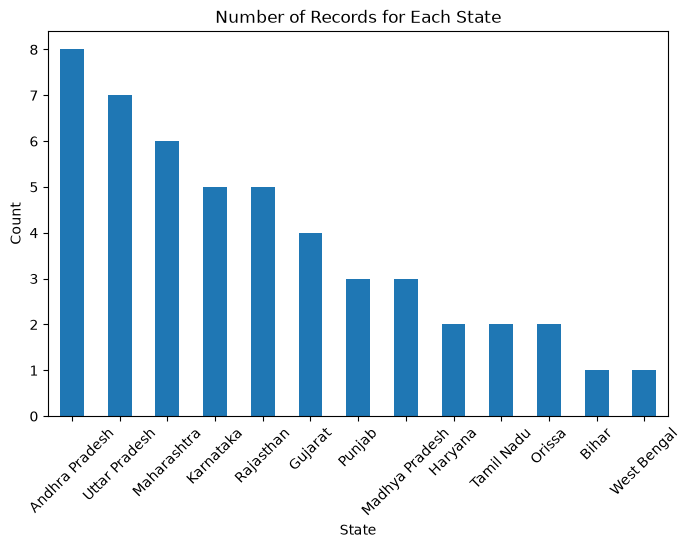

In [16]:
plt.figure(figsize=(8,5))

df["State"].value_counts().plot(kind="bar")

plt.title("Number of Records for Each State")
plt.xlabel("State")
plt.ylabel("Count")

plt.xticks(rotation=45)

plt.show()

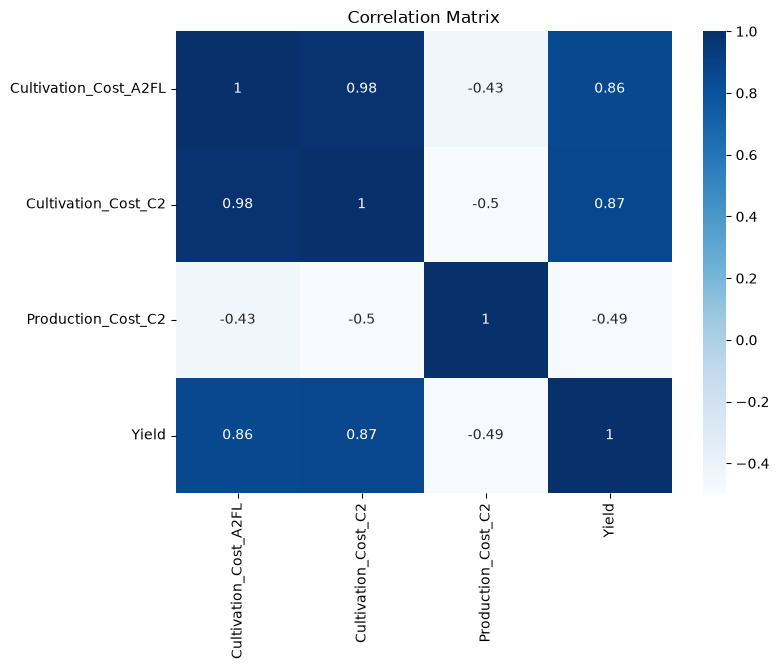

In [17]:
plt.figure(figsize=(8,6))

sns.heatmap(
    df[[
        "Cultivation_Cost_A2FL",
        "Cultivation_Cost_C2",
        "Production_Cost_C2",
        "Yield"
    ]].corr(),
    annot=True,
    cmap="Blues"
)

plt.title("Correlation Matrix")

plt.show()

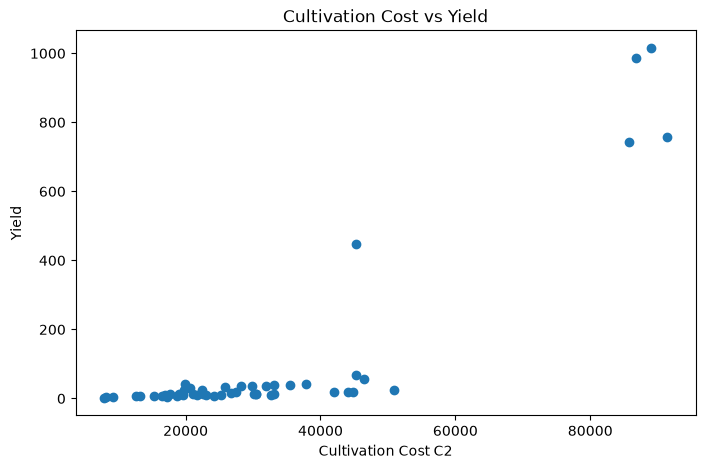

In [18]:
plt.figure(figsize=(8,5))

plt.scatter(
    df["Cultivation_Cost_C2"],
    df["Yield"]
)

plt.title("Cultivation Cost vs Yield")
plt.xlabel("Cultivation Cost C2")
plt.ylabel("Yield")

plt.show()

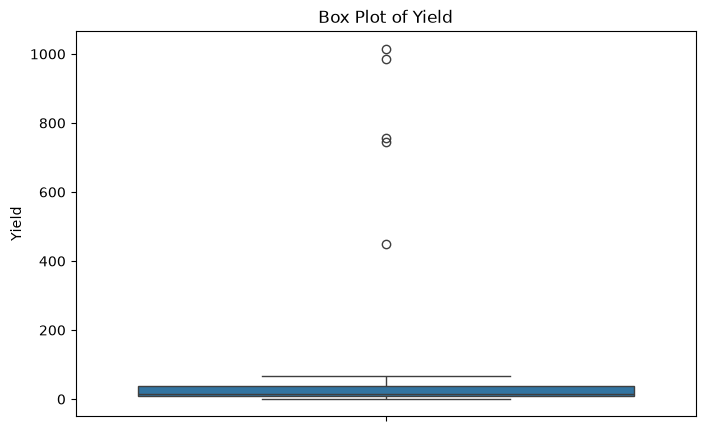

In [19]:
plt.figure(figsize=(8,5))

sns.boxplot(y=df["Yield"])

plt.title("Box Plot of Yield")

plt.show()

In [21]:
from sklearn.preprocessing import LabelEncoder

# Create LabelEncoder objects
crop_encoder = LabelEncoder()
state_encoder = LabelEncoder()

# Encode categorical columns
df["Crop"] = crop_encoder.fit_transform(df["Crop"])
df["State"] = state_encoder.fit_transform(df["State"])

# Display first five rows
df.head()

,Crop,State,Cultivation_Cost_A2FL,Cultivation_Cost_C2,Production_Cost_C2,Yield
0,0,11,9794.05,23076.74,1941.55,9.83
1,0,4,10593.15,16528.68,2172.46,7.47
2,0,2,13468.82,19551.90,1898.30,9.59
3,0,0,17051.66,24171.65,3670.54,6.42
4,0,6,17130.55,25270.26,2775.80,8.72


In [22]:
print(df.head())

   Crop  State  Cultivation_Cost_A2FL  Cultivation_Cost_C2  \
0     0     11                9794.05             23076.74   
1     0      4               10593.15             16528.68   
2     0      2               13468.82             19551.90   
3     0      0               17051.66             24171.65   
4     0      6               17130.55             25270.26   

   Production_Cost_C2  Yield  
0             1941.55   9.83  
1             2172.46   7.47  
2             1898.30   9.59  
3             3670.54   6.42  
4             2775.80   8.72  


In [45]:
# Features
X = df[
    [
        "Crop_Encoded",
        "State_Encoded",
        "Cultivation_Cost_A2FL",
        "Cultivation_Cost_C2",
        "Production_Cost_C2"
    ]
]

# Target
y = df["Yield"]

In [46]:
from sklearn.model_selection import train_test_split

# Split dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Data:", X_train.shape)
print("Testing Data :", X_test.shape)

Training Data: (39, 5)
Testing Data : (10, 5)


In [47]:
# ================================
# Linear Regression Model
# ================================

# Import Linear Regression
from sklearn.linear_model import LinearRegression

# Create the model
lr_model = LinearRegression()

# Train the model
lr_model.fit(X_train, y_train)

print("✅ Linear Regression model trained successfully!")

✅ Linear Regression model trained successfully!


In [48]:
# ================================
# Model Prediction & Evaluation
# ================================

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Make predictions
y_pred_lr = lr_model.predict(X_test)

# Calculate evaluation metrics
mae = mean_absolute_error(y_test, y_pred_lr)
mse = mean_squared_error(y_test, y_pred_lr)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred_lr)

# Display results
print("========== Linear Regression Performance ==========")
print(f"Mean Absolute Error (MAE)      : {mae:.2f}")
print(f"Mean Squared Error (MSE)       : {mse:.2f}")
print(f"Root Mean Squared Error (RMSE) : {rmse:.2f}")
print(f"R² Score                       : {r2:.4f}")

========== Linear Regression Performance ==========
Mean Absolute Error (MAE)      : 116.76
Mean Squared Error (MSE)       : 19876.70
Root Mean Squared Error (RMSE) : 140.98
R² Score                       : 0.7800


In [49]:
# ================================
# Actual vs Predicted Values
# ================================

comparison = pd.DataFrame({
    "Actual Yield": y_test,
    "Predicted Yield": y_pred_lr
})

comparison.head(10)

,Actual Yield,Predicted Yield
13,8.05,-66.171965
45,23.59,64.790659
47,34.99,160.669546
44,1015.45,726.175440
17,11.98,61.221831
27,1.32,-221.283041
26,4.05,-115.582284
25,3.01,-140.244699
31,32.42,80.269127
19,9.33,63.967884


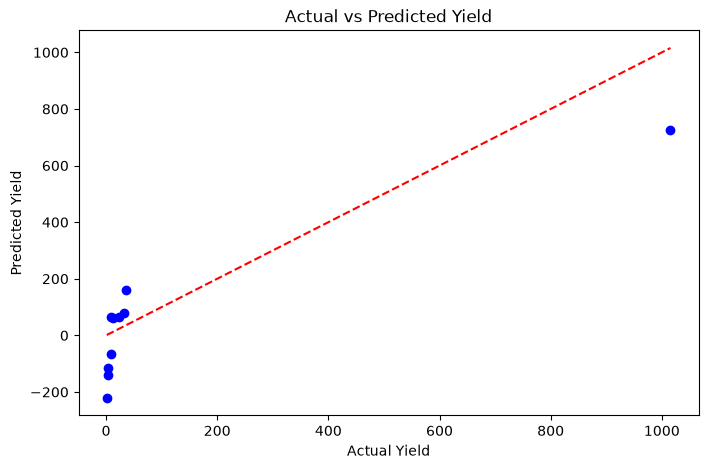

In [50]:
# ================================
# Actual vs Predicted Graph
# ================================

plt.figure(figsize=(8,5))

plt.scatter(y_test, y_pred_lr, color="blue")

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color="red",
    linestyle="--"
)

plt.title("Actual vs Predicted Yield")
plt.xlabel("Actual Yield")
plt.ylabel("Predicted Yield")

plt.show()

In [51]:
# ================================
# Decision Tree Regression Model
# ================================

from sklearn.tree import DecisionTreeRegressor

# Create the model
dt_model = DecisionTreeRegressor(random_state=42)

# Train the model
dt_model.fit(X_train, y_train)

print("✅ Decision Tree model trained successfully!")

✅ Decision Tree model trained successfully!


In [52]:
# ================================
# Decision Tree Evaluation
# ================================

# Make predictions
y_pred_dt = dt_model.predict(X_test)

# Evaluation metrics
mae_dt = mean_absolute_error(y_test, y_pred_dt)
mse_dt = mean_squared_error(y_test, y_pred_dt)
rmse_dt = np.sqrt(mse_dt)
r2_dt = r2_score(y_test, y_pred_dt)

print("========== Decision Tree Performance ==========")
print(f"Mean Absolute Error (MAE)      : {mae_dt:.2f}")
print(f"Mean Squared Error (MSE)       : {mse_dt:.2f}")
print(f"Root Mean Squared Error (RMSE) : {rmse_dt:.2f}")
print(f"R² Score                       : {r2_dt:.4f}")

========== Decision Tree Performance ==========
Mean Absolute Error (MAE)      : 60.94
Mean Squared Error (MSE)       : 32128.04
Root Mean Squared Error (RMSE) : 179.24
R² Score                       : 0.6444


In [53]:
# ================================
# Actual vs Predicted (Decision Tree)
# ================================

comparison_dt = pd.DataFrame({
    "Actual Yield": y_test,
    "Predicted Yield": y_pred_dt
})

comparison_dt.head(10)

,Actual Yield,Predicted Yield
13,8.05,9.59
45,23.59,31.10
47,34.99,39.04
44,1015.45,448.89
17,11.98,24.39
27,1.32,4.71
26,4.05,6.70
25,3.01,6.70
31,32.42,36.61
19,9.33,12.69


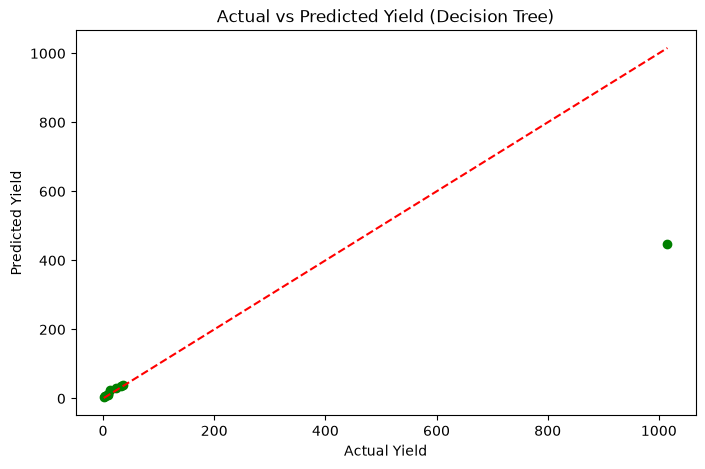

In [54]:
# ================================
# Decision Tree Prediction Graph
# ================================

plt.figure(figsize=(8,5))

plt.scatter(y_test, y_pred_dt, color="green")

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color="red",
    linestyle="--"
)

plt.title("Actual vs Predicted Yield (Decision Tree)")
plt.xlabel("Actual Yield")
plt.ylabel("Predicted Yield")

plt.show()

In [55]:
# ================================
# Random Forest Regression Model
# ================================

from sklearn.ensemble import RandomForestRegressor

# Create the model
rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

# Train the model
rf_model.fit(X_train, y_train)

print("✅ Random Forest model trained successfully!")

✅ Random Forest model trained successfully!


In [56]:
# ================================
# Random Forest Evaluation
# ================================

# Make predictions
y_pred_rf = rf_model.predict(X_test)

# Evaluation metrics
mae_rf = mean_absolute_error(y_test, y_pred_rf)
mse_rf = mean_squared_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mse_rf)
r2_rf = r2_score(y_test, y_pred_rf)

print("========== Random Forest Performance ==========")
print(f"Mean Absolute Error (MAE)      : {mae_rf:.2f}")
print(f"Mean Squared Error (MSE)       : {mse_rf:.2f}")
print(f"Root Mean Squared Error (RMSE) : {rmse_rf:.2f}")
print(f"R² Score                       : {r2_rf:.4f}")

========== Random Forest Performance ==========
Mean Absolute Error (MAE)      : 28.43
Mean Squared Error (MSE)       : 4852.64
Root Mean Squared Error (RMSE) : 69.66
R² Score                       : 0.9463


In [57]:
# ================================
# Actual vs Predicted (Random Forest)
# ================================

comparison_rf = pd.DataFrame({
    "Actual Yield": y_test,
    "Predicted Yield": y_pred_rf
})

comparison_rf.head(10)

,Actual Yield,Predicted Yield
13,8.05,8.9099
45,23.59,49.7925
47,34.99,46.8550
44,1015.45,797.3447
17,11.98,16.3884
27,1.32,6.3088
26,4.05,7.2594
25,3.01,6.8473
31,32.42,38.1995
19,9.33,14.3888


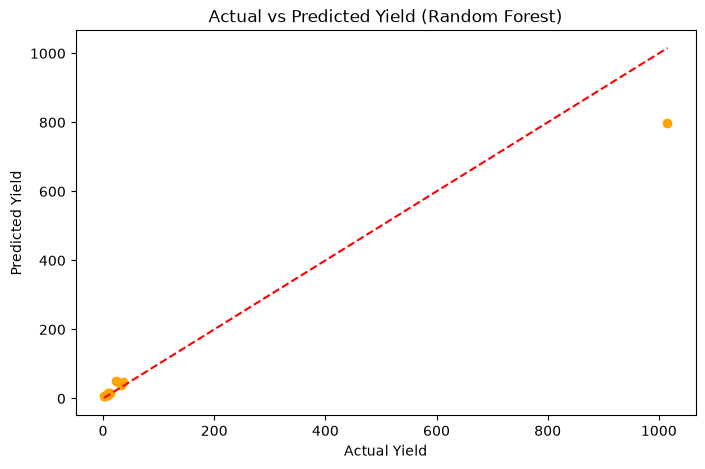

In [58]:
# ================================
# Random Forest Prediction Graph
# ================================

plt.figure(figsize=(8,5))

plt.scatter(y_test, y_pred_rf, color="orange")

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color="red",
    linestyle="--"
)

plt.title("Actual vs Predicted Yield (Random Forest)")
plt.xlabel("Actual Yield")
plt.ylabel("Predicted Yield")

plt.show()

In [59]:
# ================================
# Compare All Models
# ================================

comparison = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Decision Tree",
        "Random Forest"
    ],
    "MAE": [
        mae,
        mae_dt,
        mae_rf
    ],
    "RMSE": [
        rmse,
        rmse_dt,
        rmse_rf
    ],
    "R2 Score": [
        r2,
        r2_dt,
        r2_rf
    ]
})

comparison.sort_values(by="R2 Score", ascending=False)

,Model,MAE,RMSE,R2 Score
2,Random Forest,28.43149,69.660858,0.946283
0,Linear Regression,116.75956,140.984756,0.779973
1,Decision Tree,60.93500,179.242961,0.644356


In [60]:
# ================================
# Save Random Forest Model
# ================================

import joblib

joblib.dump(rf_model, "../model/crop_prediction_model.pkl")

print("✅ Model saved successfully!")

✅ Model saved successfully!


In [61]:
# ================================
# Save Label Encoders
# ================================

joblib.dump(crop_encoder, "../model/crop_encoder.pkl")
joblib.dump(state_encoder, "../model/state_encoder.pkl")

print("✅ Encoders saved successfully!")

✅ Encoders saved successfully!


In [62]:
# ================================
# Feature Importance
# ================================

feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance

,Feature,Importance
4,Production_Cost_C2,0.713173
2,Cultivation_Cost_A2FL,0.133570
3,Cultivation_Cost_C2,0.122396
0,Crop_Encoded,0.017724
1,State_Encoded,0.013135


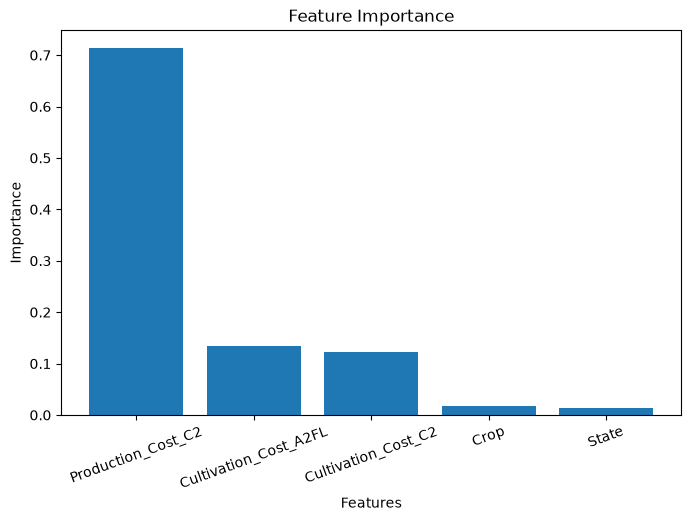

In [41]:
# ================================
# Feature Importance Graph
# ================================

plt.figure(figsize=(8,5))

plt.bar(
    feature_importance["Feature"],
    feature_importance["Importance"]
)

plt.title("Feature Importance")
plt.xlabel("Features")
plt.ylabel("Importance")

plt.xticks(rotation=20)

plt.show()

In [43]:
# Reload the original dataset

df = pd.read_csv("../data/datafile (1).csv")

# Rename columns
df.columns = [
    "Crop",
    "State",
    "Cultivation_Cost_A2FL",
    "Cultivation_Cost_C2",
    "Production_Cost_C2",
    "Yield"
]

df.head()

,Crop,State,Cultivation_Cost_A2FL,Cultivation_Cost_C2,Production_Cost_C2,Yield
0,ARHAR,Uttar Pradesh,9794.05,23076.74,1941.55,9.83
1,ARHAR,Karnataka,10593.15,16528.68,2172.46,7.47
2,ARHAR,Gujarat,13468.82,19551.90,1898.30,9.59
3,ARHAR,Andhra Pradesh,17051.66,24171.65,3670.54,6.42
4,ARHAR,Maharashtra,17130.55,25270.26,2775.80,8.72


In [63]:
from sklearn.preprocessing import LabelEncoder

# Create encoders
crop_encoder = LabelEncoder()
state_encoder = LabelEncoder()

# Create NEW encoded columns
df["Crop_Encoded"] = crop_encoder.fit_transform(df["Crop"])
df["State_Encoded"] = state_encoder.fit_transform(df["State"])

# Verify
df.head()

,Crop,State,Cultivation_Cost_A2FL,Cultivation_Cost_C2,Production_Cost_C2,Yield,Crop_Encoded,State_Encoded
0,ARHAR,Uttar Pradesh,9794.05,23076.74,1941.55,9.83,0,11
1,ARHAR,Karnataka,10593.15,16528.68,2172.46,7.47,0,4
2,ARHAR,Gujarat,13468.82,19551.90,1898.30,9.59,0,2
3,ARHAR,Andhra Pradesh,17051.66,24171.65,3670.54,6.42,0,0
4,ARHAR,Maharashtra,17130.55,25270.26,2775.80,8.72,0,6


In [64]:
print(crop_encoder.classes_)
print(state_encoder.classes_)

['ARHAR' 'COTTON' 'GRAM' 'GROUNDNUT' 'MAIZE' 'MOONG' 'PADDY'
 'RAPESEED AND MUSTARD' 'SUGARCANE' 'WHEAT']
['Andhra Pradesh' 'Bihar' 'Gujarat' 'Haryana' 'Karnataka' 'Madhya Pradesh'
 'Maharashtra' 'Orissa' 'Punjab' 'Rajasthan' 'Tamil Nadu' 'Uttar Pradesh'
 'West Bengal']


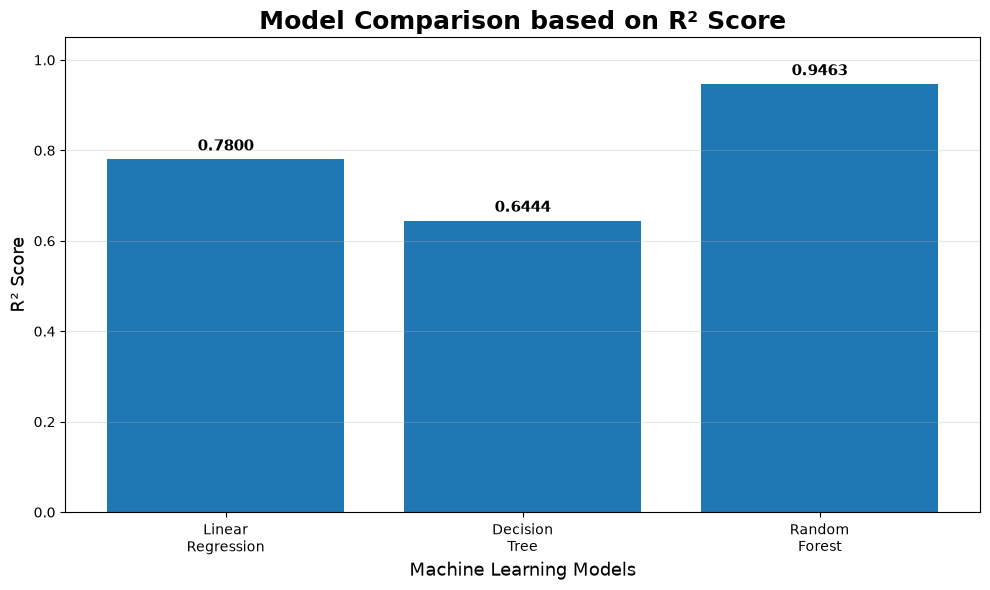

In [1]:
import matplotlib.pyplot as plt

# -------------------------------
# Model Performance Data
# -------------------------------

models = [
    "Linear\nRegression",
    "Decision\nTree",
    "Random\nForest"
]

mae = [116.76, 60.94, 28.43]
rmse = [140.98, 179.24, 69.66]
r2 = [0.7800, 0.6444, 0.9463]

# -------------------------------
# Figure
# -------------------------------

plt.figure(figsize=(10,6))

plt.bar(models, r2)

plt.title(
    "Model Comparison based on R² Score",
    fontsize=18,
    fontweight="bold"
)

plt.xlabel("Machine Learning Models", fontsize=13)
plt.ylabel("R² Score", fontsize=13)

plt.ylim(0,1.05)

# Add value labels
for i, value in enumerate(r2):
    plt.text(
        i,
        value + 0.02,
        f"{value:.4f}",
        ha="center",
        fontsize=11,
        fontweight="bold"
    )

plt.grid(axis="y", alpha=0.3)

plt.tight_layout()

plt.savefig(
    "model_comparison_r2.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()